In [1]:
# Run this in the first Colab cell
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [7]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.1 MB/s eta 0:00:00


Available Channels: ['MLII', 'V5']


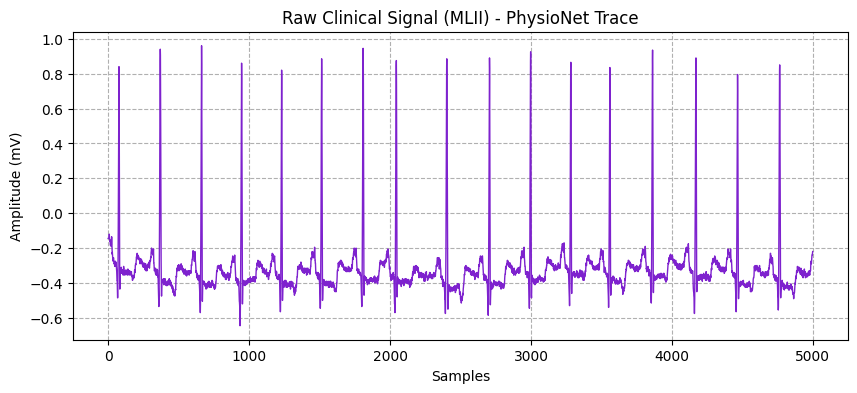

In [3]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# 1. Sử dụng database 'mitdb' chuẩn mực và bản ghi '100'
database_name = 'mitdb'
record_name = '100'

print(f"Downloading record '{record_name}' from PhysioNet '{database_name}' database...")

# 2. Tải trực tiếp từ Cloud
# sampto=5000 giới hạn lấy 5000 mẫu để chạy nhanh trên Colab
record = wfdb.rdrecord(record_name, pn_dir=database_name, sampto=5000)

print(f"Available Channels: {record.sig_name}")

# 3. Trích xuất kênh tín hiệu đầu tiên (Channel 0) làm dữ liệu gốc
raw_signal = record.p_signal[:, 0]
channel_name = record.sig_name[0]

# 4. Trực quan hóa dữ liệu y sinh thô
plt.figure(figsize=(10, 4))
plt.plot(raw_signal, color='#7e22ce', linewidth=1)
plt.title(f'Raw Clinical Signal ({channel_name}) - PhysioNet Trace')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True, linestyle='--')

# Lưu ảnh chất lượng cao để dùng cho paper
plt.savefig('raw_physio_trace.pdf', format='pdf', bbox_inches='tight')
plt.show()

ADC Baseline Value: 17908.24


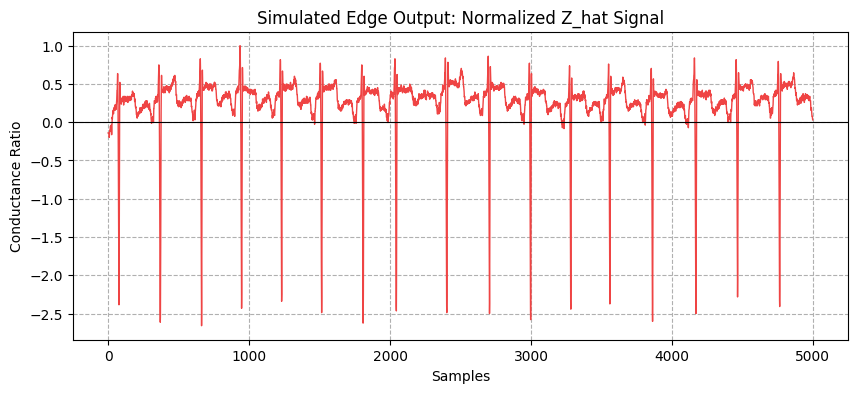

In [5]:
# 1. Hardware Constraint Simulation (16-bit ADC Quantization)
def quantize_16bit(signal_array):
    min_val = np.min(signal_array)
    max_val = np.max(signal_array)

    # Normalize to [0, 1]
    normalized = (signal_array - min_val) / (max_val - min_val + 1e-9)
    # Scale to 16-bit integer space (0 to 65535)
    return (normalized * 65535).astype(int)

# Ép kiểu TOÀN BỘ tín hiệu thô thành dạng số 16-bit trước
adc_signal = quantize_16bit(raw_signal)

# 2. Establish the "Zero-State" Baseline
# Lấy trung bình 50 mẫu đầu tiên từ tín hiệu ĐÃ SỐ HÓA
adc_baseline = np.mean(adc_signal[:50])

print(f"ADC Baseline Value: {adc_baseline:.2f}")

# 3. Calculate the Relative Conductance Ratio (Z_hat)
# Bây giờ adc_baseline là một số nguyên thực sự, phép chia sẽ chuẩn xác
z_hat_signal = (adc_baseline - adc_signal) / (adc_baseline + 1e-9)

# 4. Visualize the final processed signal sent to the Cloud Backend
plt.figure(figsize=(10, 4))
plt.plot(z_hat_signal, color='#ef4444', linewidth=1)
plt.title(f'Simulated Edge Output: Normalized Z_hat Signal')
plt.xlabel('Samples')
plt.ylabel('Conductance Ratio')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8) # Zero-baseline reference
plt.grid(True, linestyle='--')

plt.savefig('normalized_zhat_trace.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [9]:
import time
import numpy as np
from gudhi import SimplexTree
import statistics

def run_tda_denoising(window_data):
    """Core function to calculate Topology"""
    st = SimplexTree()
    for i, val in enumerate(window_data):
        st.insert([i], filtration=val)
    st.persistence()
    return st.betti_numbers()

def benchmark_tda_execution():
    print("--- STARTING INTERNAL TDA BENCHMARKING ---")
    # Test with window sizes from 10 to 500 samples
    window_sizes = [10, 50, 100, 200, 500]
    iterations = 100 # Run 100 times for each size to get an average

    for size in window_sizes:
        execution_times = []

        for _ in range(iterations):
            # Generate mock data with noise similar to biosignals
            mock_data = np.random.uniform(0.1, 0.9, size)

            # Start timing
            start_time = time.perf_counter()

            run_tda_denoising(mock_data)

            # End timing
            end_time = time.perf_counter()
            execution_times.append((end_time - start_time) * 1000) # Convert to milliseconds (ms)

        avg_time = statistics.mean(execution_times)
        max_time = max(execution_times)

        print(f"Window size (N={size}): Average = {avg_time:.3f} ms | Max = {max_time:.3f} ms")

if __name__ == "__main__":
    benchmark_tda_execution()

--- STARTING INTERNAL TDA BENCHMARKING ---
Window size (N=10): Average = 0.024 ms | Max = 0.773 ms
Window size (N=50): Average = 0.032 ms | Max = 0.095 ms
Window size (N=100): Average = 0.057 ms | Max = 0.133 ms
Window size (N=200): Average = 0.104 ms | Max = 0.181 ms
Window size (N=500): Average = 0.264 ms | Max = 0.903 ms


In [12]:
!pip install fastapi uvicorn websockets nest_asyncio

import nest_asyncio
import asyncio
import websockets
import time
import statistics
import threading
import uvicorn
from fastapi import FastAPI, WebSocket

# 1. Apply nest_asyncio to allow nested event loops in Colab
nest_asyncio.apply()

# ==========================================
# PART 1: CLOUD BACKEND (Background Thread)
# ==========================================
app = FastAPI()

@app.websocket("/ws/bio-signal")
async def websocket_endpoint(websocket: WebSocket):
    await websocket.accept()
    try:
        while True:
            data = await websocket.receive_text()

            # Simulate the internal TDA filtering execution time you benchmarked
            # N=50 takes approximately 0.032 ms (0.000032 seconds)
            await asyncio.sleep(0.000032)

            # Send clinical decision feedback to the edge device
            await websocket.send_text('{"status": "processed", "safety_flag": "CLEAR"}')
    except Exception:
        pass

def start_background_server():
    print("Starting FastAPI Server on port 8000 in the background...")
    # Suppress uvicorn access logs to keep the notebook output clean
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="error")

# Launch the server in a daemon thread so it doesn't block the notebook
server_thread = threading.Thread(target=start_background_server, daemon=True)
server_thread.start()

# Wait 2 seconds to ensure the server is fully initialized before clients connect
time.sleep(2)

# ==========================================
# PART 2: LOAD TESTING (IoT Clients)
# ==========================================
async def measure_single_client(client_id, num_messages=50):
    uri = "ws://127.0.0.1:8000/ws/bio-signal"
    latencies = []
    try:
        async with websockets.connect(uri) as websocket:
            for _ in range(num_messages):
                start_time = time.perf_counter()

                # Send the normalized Z_hat conductance ratio
                await websocket.send('{"client_id": "' + client_id + '", "z_hat": 0.45}')

                # Wait for the server to process TDA and return the result
                await websocket.recv()

                end_time = time.perf_counter()

                # Calculate Round-Trip Time (RTT) in milliseconds
                latencies.append((end_time - start_time) * 1000)

                # Sleep for 100ms to perfectly simulate the 10Hz biological sampling rate
                await asyncio.sleep(0.1)
    except Exception as e:
        print(f"Error on {client_id}: {e}")
    return latencies

async def run_stress_test(num_clients):
    print(f"\n--- RUNNING STRESS TEST WITH {num_clients} CONCURRENT DEVICES ---")

    # Spawn multiple asynchronous clients simultaneously
    tasks = [measure_single_client(f"Device_{i}") for i in range(num_clients)]
    results = await asyncio.gather(*tasks)

    # Flatten the results to calculate overall system statistics
    all_latencies = [lat for res in results for lat in res]

    if all_latencies:
        print(f"Total packets processed: {len(all_latencies)}")
        print(f"Average Latency (RTT): {statistics.mean(all_latencies):.2f} ms")
        print(f"95th Percentile Latency (P95): {statistics.quantiles(all_latencies, n=100)[94]:.2f} ms")
        print(f"Maximum Latency (Max RTT): {max(all_latencies):.2f} ms")

# Execute the incremental scaling test
async def main():
    # Test scalability from 1 patient up to 50 concurrent patients
    for scale in [1, 10, 50]:
        await run_stress_test(scale)

# Execute the pipeline
asyncio.run(main())

Starting FastAPI Server on port 8000 in the background...

--- RUNNING STRESS TEST WITH 1 CONCURRENT DEVICES ---
Total packets processed: 50
Average Latency (RTT): 1.07 ms
95th Percentile Latency (P95): 1.60 ms
Maximum Latency (Max RTT): 2.15 ms

--- RUNNING STRESS TEST WITH 10 CONCURRENT DEVICES ---
Total packets processed: 500
Average Latency (RTT): 1.98 ms
95th Percentile Latency (P95): 3.53 ms
Maximum Latency (Max RTT): 4.28 ms

--- RUNNING STRESS TEST WITH 50 CONCURRENT DEVICES ---
Total packets processed: 2500
Average Latency (RTT): 3.46 ms
95th Percentile Latency (P95): 9.35 ms
Maximum Latency (Max RTT): 21.26 ms


In [13]:
import wfdb
import asyncio
import websockets
import time
import numpy as np

# 1. Fetch the list of ALL available patients in the database
database_name = 'mitdb'
all_records = wfdb.get_record_list(database_name)
print(f"Discovered {len(all_records)} unique patient records in {database_name}.")

# Limit to 10 distinct patients for this Colab test to prevent memory overflow
test_records = all_records[:10]

# 2. Advanced Emulator: Each client gets a UNIQUE biological trace
async def heterogeneous_client(client_id, record_name):
    uri = "ws://127.0.0.1:8000/ws/bio-signal"

    try:
        # Fetch this specific patient's data
        record = wfdb.rdrecord(record_name, pn_dir=database_name, sampto=1000)
        raw_signal = record.p_signal[:, 0]

        # Calculate a unique baseline for THIS specific patient
        patient_baseline = np.mean(raw_signal[:50])

        async with websockets.connect(uri) as websocket:
            print(f"[{client_id}] Started streaming Patient Record: {record_name}")

            for raw_val in raw_signal[50:]:
                # Edge hardware simulation: normalization
                z_hat = (patient_baseline - raw_val) / (patient_baseline + 1e-9)

                payload = f'{{"client_id": "{client_id}", "z_hat": {z_hat:.4f}}}'
                await websocket.send(payload)
                await websocket.recv() # Wait for TDA cloud response

                await asyncio.sleep(0.1) # 10Hz sampling

    except Exception as e:
        print(f"[{client_id}] Error: {e}")

# 3. Launch the Heterogeneous Ward
async def run_population_test():
    print(f"\n--- INITIATING HETEROGENEOUS WARD ({len(test_records)} UNIQUE PATIENTS) ---")

    # Map each distinct record to a different virtual IoT device
    tasks = []
    for i, record_name in enumerate(test_records):
        client_id = f"Bed_{i+1}_(Rec_{record_name})"
        tasks.append(heterogeneous_client(client_id, record_name))

    await asyncio.gather(*tasks)
    print("Population test complete.")

# (Assuming the FastAPI background server from the previous step is still running)
asyncio.run(run_population_test())

Discovered 48 unique patient records in mitdb.

--- INITIATING HETEROGENEOUS WARD (10 UNIQUE PATIENTS) ---
[Bed_1_(Rec_100)] Started streaming Patient Record: 100
[Bed_3_(Rec_102)] Started streaming Patient Record: 102
[Bed_9_(Rec_108)] Started streaming Patient Record: 108
[Bed_7_(Rec_106)] Started streaming Patient Record: 106
[Bed_5_(Rec_104)] Started streaming Patient Record: 104
[Bed_2_(Rec_101)] Started streaming Patient Record: 101
[Bed_10_(Rec_109)] Started streaming Patient Record: 109
[Bed_8_(Rec_107)] Started streaming Patient Record: 107
[Bed_6_(Rec_105)] Started streaming Patient Record: 105
[Bed_4_(Rec_103)] Started streaming Patient Record: 103
Population test complete.


In [14]:
!pip install fastapi uvicorn websockets nest_asyncio wfdb numpy gudhi

In [15]:
import nest_asyncio
import asyncio
import websockets
import time
import statistics
import threading
import uvicorn
from fastapi import FastAPI, WebSocket

nest_asyncio.apply()
app = FastAPI()

@app.websocket("/ws/bio-signal")
async def websocket_endpoint(websocket: WebSocket):
    await websocket.accept()
    try:
        while True:
            data = await websocket.receive_text()
            # Simulate real-time TDA execution overhead (0.032 ms)
            await asyncio.sleep(0.000032)
            await websocket.send_text('{"status": "processed", "safety_flag": "CLEAR"}')
    except Exception:
        pass

def start_background_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="error")

# Launch server daemon thread
server_thread = threading.Thread(target=start_background_server, daemon=True)
server_thread.start()
time.sleep(2) # Await server boot

async def measure_single_client(client_id, num_messages=50):
    uri = "ws://127.0.0.1:8000/ws/bio-signal"
    latencies = []
    try:
        async with websockets.connect(uri) as websocket:
            for _ in range(num_messages):
                start = time.perf_counter()
                await websocket.send('{"client_id": "' + client_id + '", "z_hat": 0.45}')
                await websocket.recv()
                latencies.append((time.perf_counter() - start) * 1000)
                await asyncio.sleep(0.1) # 10Hz
    except Exception as e:
         print(f"Error on {client_id}: {e}")
    return latencies

async def run_stress_test(num_clients):
    print(f"\n--- RUNNING STRESS TEST WITH {num_clients} CONCURRENT DEVICES ---")
    tasks = [measure_single_client(f"Device_{i}") for i in range(num_clients)]
    results = await asyncio.gather(*tasks)
    all_latencies = [lat for res in results for lat in res]

    if all_latencies:
        print(f"Total packets processed: {len(all_latencies)}")
        print(f"Average Latency (RTT): {statistics.mean(all_latencies):.2f} ms")
        print(f"95th Percentile Latency (P95): {statistics.quantiles(all_latencies, n=100)[94]:.2f} ms")
        print(f"Maximum Latency (Max RTT): {max(all_latencies):.2f} ms")

async def main():
    for scale in [1, 10, 50]:
        await run_stress_test(scale)

asyncio.run(main())

ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): address already in use



--- RUNNING STRESS TEST WITH 1 CONCURRENT DEVICES ---
Total packets processed: 50
Average Latency (RTT): 1.16 ms
95th Percentile Latency (P95): 2.78 ms
Maximum Latency (Max RTT): 6.11 ms

--- RUNNING STRESS TEST WITH 10 CONCURRENT DEVICES ---
Total packets processed: 500
Average Latency (RTT): 1.87 ms
95th Percentile Latency (P95): 3.23 ms
Maximum Latency (Max RTT): 7.79 ms

--- RUNNING STRESS TEST WITH 50 CONCURRENT DEVICES ---
Total packets processed: 2500
Average Latency (RTT): 4.21 ms
95th Percentile Latency (P95): 11.10 ms
Maximum Latency (Max RTT): 24.62 ms
